In [16]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Split + Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Feature Selection
from sklearn.feature_selection import SequentialFeatureSelector

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Tuning
from sklearn.model_selection import GridSearchCV

In [17]:
df = pd.read_csv("../PHASE-1/Data/heart_cleaned.csv")
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1


In [18]:
print(df.shape)

(918, 16)


In [19]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
lr = LogisticRegression(
    solver='liblinear',
    max_iter=5000
)

forward_selector = SequentialFeatureSelector(
    lr,
    n_features_to_select=5,
    direction='forward',
    cv=5
)

forward_selector.fit(
    X_train_scaled,
    y_train
)

forward_features = X.columns[
    forward_selector.get_support()
]

print("Forward Selected Features:")
print(forward_features)

Forward Selected Features:
Index(['Oldpeak', 'Sex_M', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'], dtype='str')


Forward Selected Features

In [23]:
X_train_forward = X_train[forward_features]
X_test_forward = X_test[forward_features]

In [24]:
scaler_f = StandardScaler()

X_train_forward = scaler_f.fit_transform(X_train_forward)
X_test_forward = scaler_f.transform(X_test_forward)

In [25]:
backward_selector = SequentialFeatureSelector(
    lr,
    n_features_to_select=5,
    direction='backward',
    cv=5
)

backward_selector.fit(
    X_train_scaled,
    y_train
)

backward_features = X.columns[
    backward_selector.get_support()
]

print("Backward Selected Features:")
print(backward_features)

Backward Selected Features:
Index(['Sex_M', 'ChestPainType_NAP', 'ChestPainType_TA', 'ExerciseAngina_Y',
       'ST_Slope_Up'],
      dtype='str')


Backward Selected Features

In [26]:
X_train_backward = X_train[backward_features]
X_test_backward = X_test[backward_features]

In [27]:
scaler_b = StandardScaler()

X_train_backward = scaler_b.fit_transform(X_train_backward)
X_test_backward = scaler_b.transform(X_test_backward)

In [28]:
models = {
    "Logistic Regression":
        LogisticRegression(max_iter=5000),

    "KNN":
        KNeighborsClassifier(),

    "SVM":
        SVC(probability=True),

    "Decision Tree":
        DecisionTreeClassifier(),

    "Random Forest":
        RandomForestClassifier()
}

In [29]:
def evaluate_models(Xtr, Xte, ytr, yte):

    results=[]

    for name, model in models.items():

        model.fit(Xtr,ytr)

        pred = model.predict(Xte)

        acc = accuracy_score(yte,pred)
        prec = precision_score(yte,pred)
        rec = recall_score(yte,pred)
        f1 = f1_score(yte,pred)

        roc = roc_auc_score(
            yte,
            model.predict_proba(Xte)[:,1]
        )

        results.append(
            [name,acc,prec,rec,f1,roc]
        )

    return pd.DataFrame(
        results,
        columns=[
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC"
        ]
    )

In [30]:
full_results = evaluate_models(
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

full_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.842391,0.906250,0.813084,0.857143,0.925112
1,KNN,0.847826,0.898990,0.831776,0.864078,0.916009
2,SVM,0.858696,0.900990,0.850467,0.875000,0.914553
3,Decision Tree,0.750000,0.827957,0.719626,0.770000,0.755917
4,Random Forest,0.847826,0.876190,0.859813,0.867925,0.930513


In [31]:
forward_results = evaluate_models(
    X_train_forward,
    X_test_forward,
    y_train,
    y_test
)

forward_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.809783,0.867347,0.794393,0.829268,0.865093
1,KNN,0.798913,0.830189,0.822430,0.826291,0.849618
2,SVM,0.793478,0.841584,0.794393,0.817308,0.799430
3,Decision Tree,0.777174,0.843750,0.757009,0.798030,0.845976
4,Random Forest,0.798913,0.836538,0.813084,0.824645,0.855262


In [32]:
backward_results = evaluate_models(
    X_train_backward,
    X_test_backward,
    y_train,
    y_test
)

backward_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.815217,0.868687,0.803738,0.834951,0.880386
1,KNN,0.804348,0.890110,0.757009,0.818182,0.836509
2,SVM,0.804348,0.851485,0.803738,0.826923,0.874196
3,Decision Tree,0.793478,0.834951,0.803738,0.819048,0.874621
4,Random Forest,0.793478,0.834951,0.803738,0.819048,0.876927


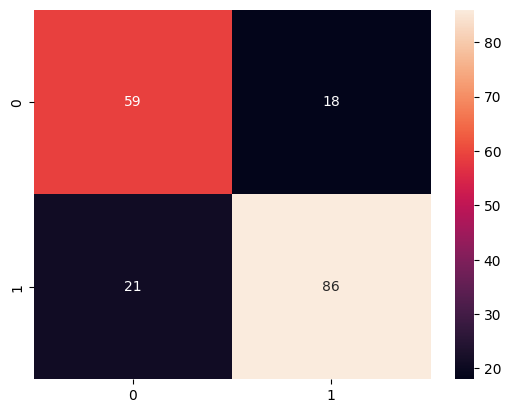

In [33]:
rf = RandomForestClassifier()

rf.fit(
    X_train_forward,
    y_train
)

pred = rf.predict(
    X_test_forward
)

cm = confusion_matrix(
    y_test,
    pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)
plt.show()

Best Classifier

In [34]:
print("Full Features")
print(full_results)

print("Forward Selection")
print(forward_results)

print("Backward Selection")
print(backward_results)

Full Features
                 Model  Accuracy  Precision    Recall        F1   ROC_AUC
0  Logistic Regression  0.842391   0.906250  0.813084  0.857143  0.925112
1                  KNN  0.847826   0.898990  0.831776  0.864078  0.916009
2                  SVM  0.858696   0.900990  0.850467  0.875000  0.914553
3        Decision Tree  0.750000   0.827957  0.719626  0.770000  0.755917
4        Random Forest  0.847826   0.876190  0.859813  0.867925  0.930513
Forward Selection
                 Model  Accuracy  Precision    Recall        F1   ROC_AUC
0  Logistic Regression  0.809783   0.867347  0.794393  0.829268  0.865093
1                  KNN  0.798913   0.830189  0.822430  0.826291  0.849618
2                  SVM  0.793478   0.841584  0.794393  0.817308  0.799430
3        Decision Tree  0.777174   0.843750  0.757009  0.798030  0.845976
4        Random Forest  0.798913   0.836538  0.813084  0.824645  0.855262
Backward Selection
                 Model  Accuracy  Precision    Recall        

In [35]:
param_grid = {
    'n_estimators':[100,200,300],
    'max_depth':[3,5,10,None]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=5
)

grid.fit(
    X_train_forward,
    y_train
)

print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 100}


In [36]:
best_rf = grid.best_estimator_

pred = best_rf.predict(
    X_test_forward
)

print(
accuracy_score(
y_test,
pred
)
)

0.7880434782608695
